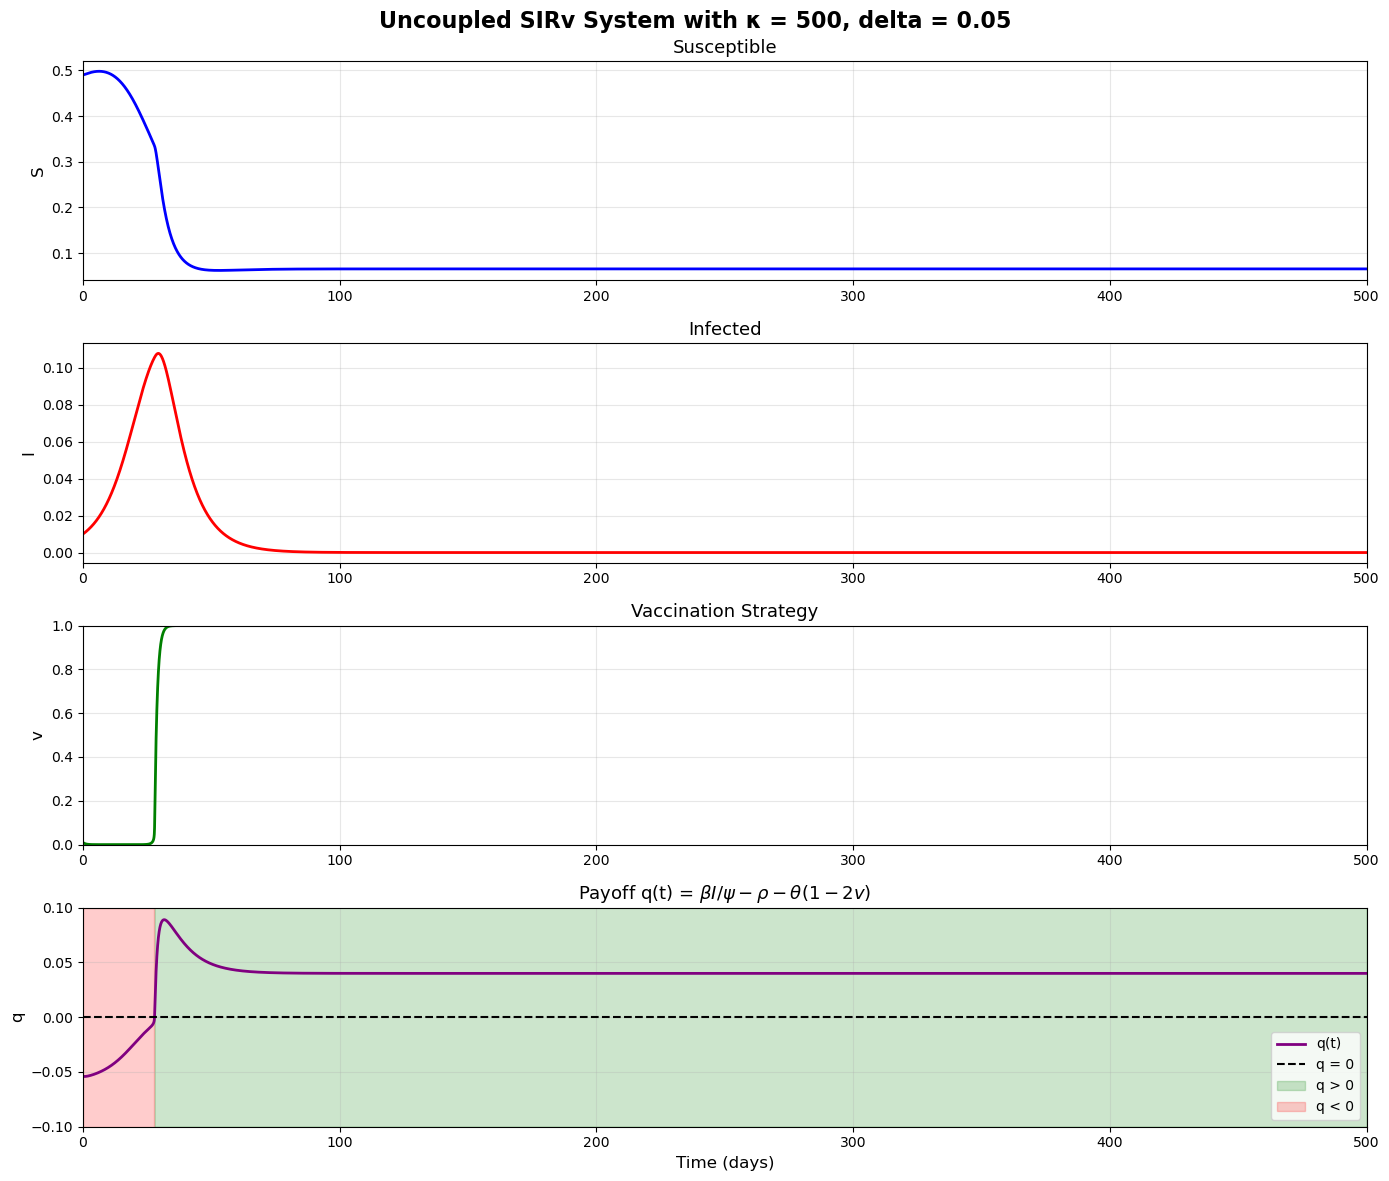

SIMULATION RESULTS (κ = 500)

Final values at t = 500.0 days:
S = 0.065421
I = -0.000000
v = 1.000000
q = 0.04000000

PAYOFF q STATISTICS
Mean q: 0.03712111
Min q: -0.05413426
Max q: 0.08900945
Std q: 0.01908053
Fraction of time q > 0: 0.9442
Fraction of time q < 0: 0.0558


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.05,
    'kappa': 500,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 1
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 500, delta = 0.05', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

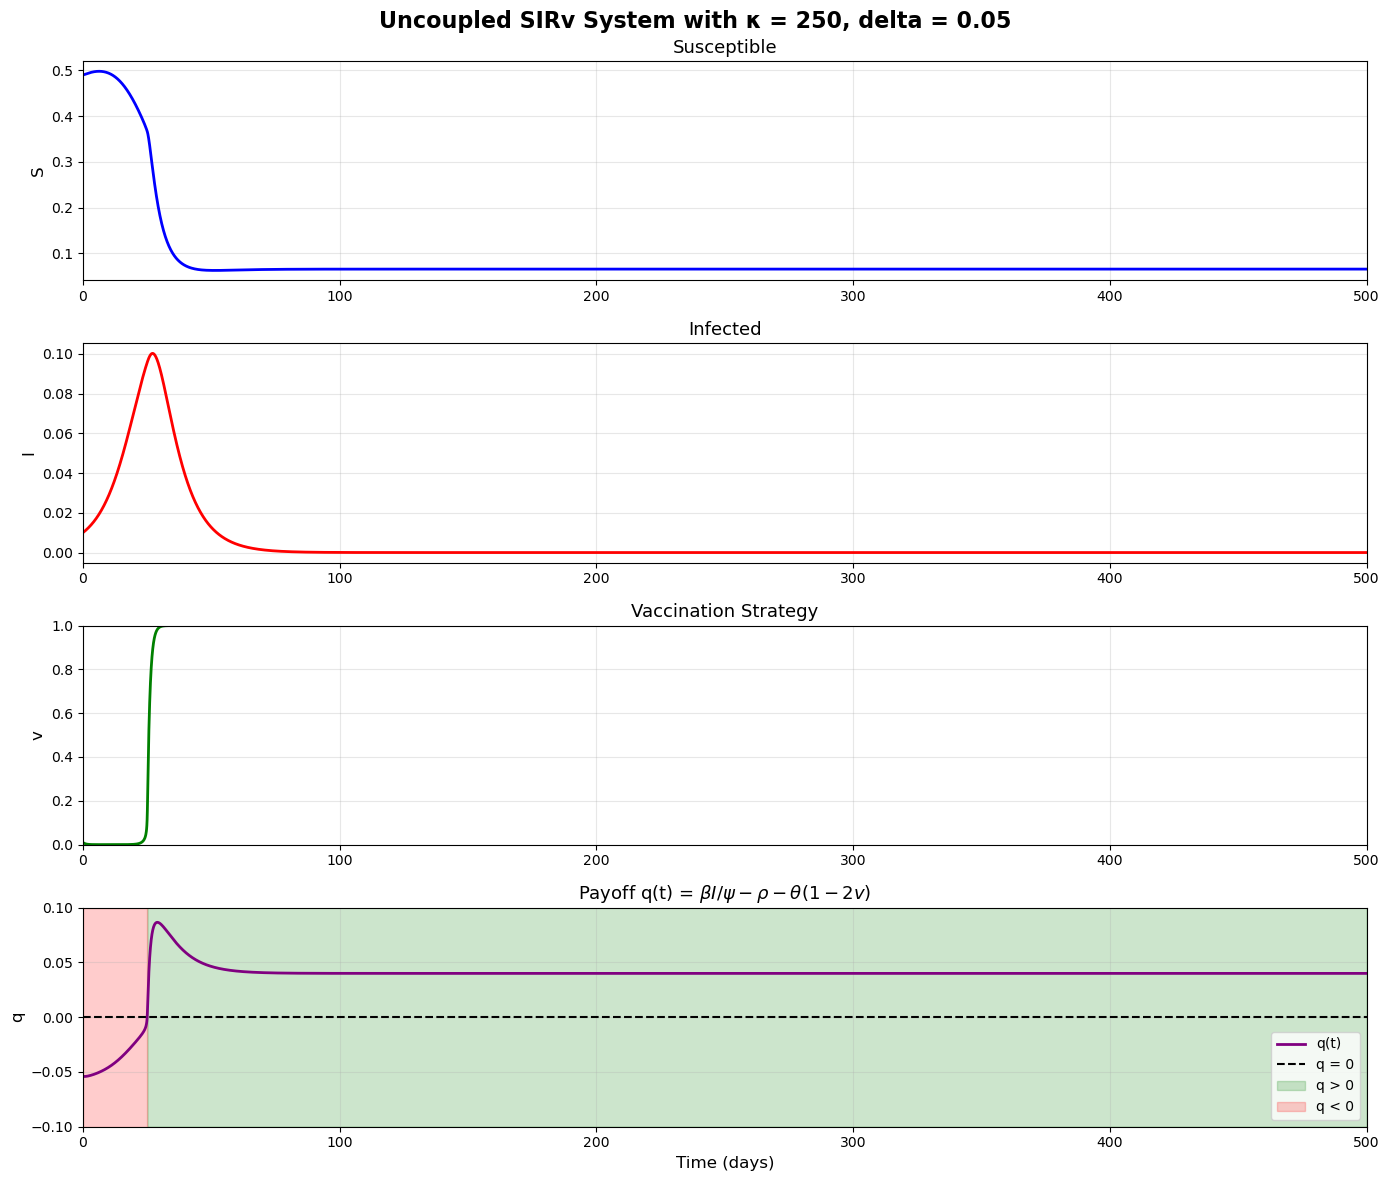

SIMULATION RESULTS (κ = 250)

Final values at t = 500.0 days:
S = 0.065423
I = -0.000000
v = 0.999955
q = 0.03999546

PAYOFF q STATISTICS
Mean q: 0.03737158
Min q: -0.05413420
Max q: 0.08661069
Std q: 0.01864143
Fraction of time q > 0: 0.9498
Fraction of time q < 0: 0.0502


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.05,
    'kappa': 250,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 1
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 250, delta = 0.05', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

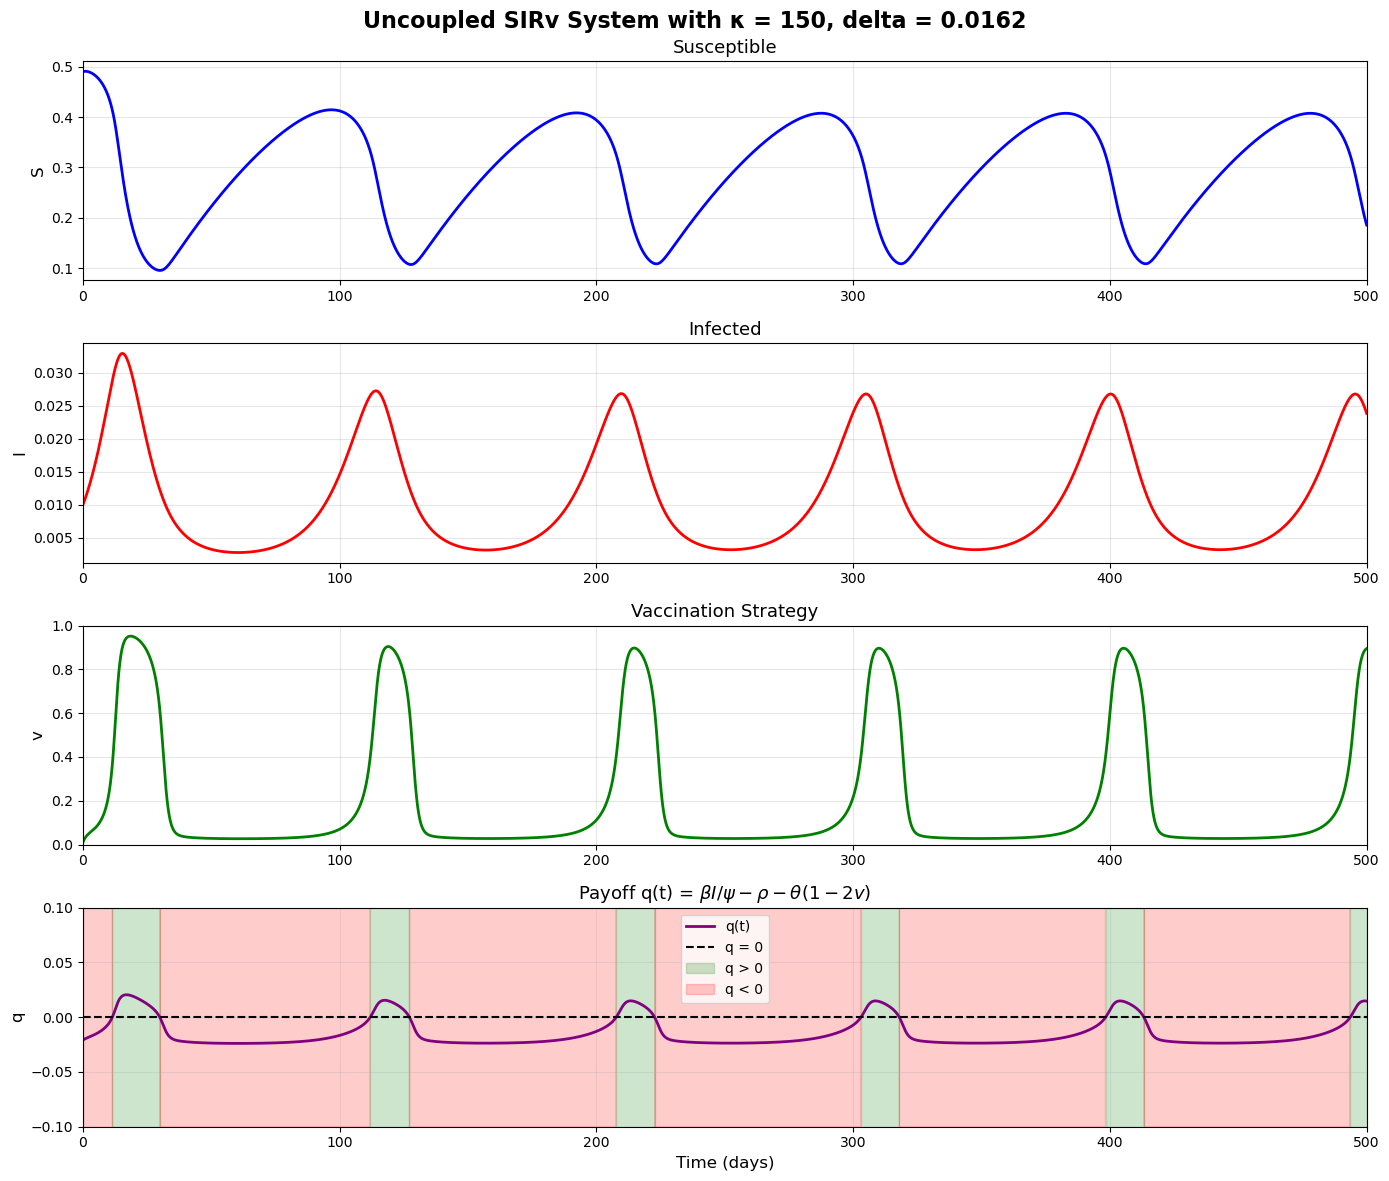

SIMULATION RESULTS (κ = 150)

Final values at t = 500.0 days:
S = 0.185563
I = 0.023823
v = 0.894784
q = 0.01470252

PAYOFF q STATISTICS
Mean q: -0.01450322
Min q: -0.02393409
Max q: 0.02048260
Std q: 0.01266129
Fraction of time q > 0: 0.1702
Fraction of time q < 0: 0.8298


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.0162,
    'kappa': 150,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 1
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 150, delta = 0.0162', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

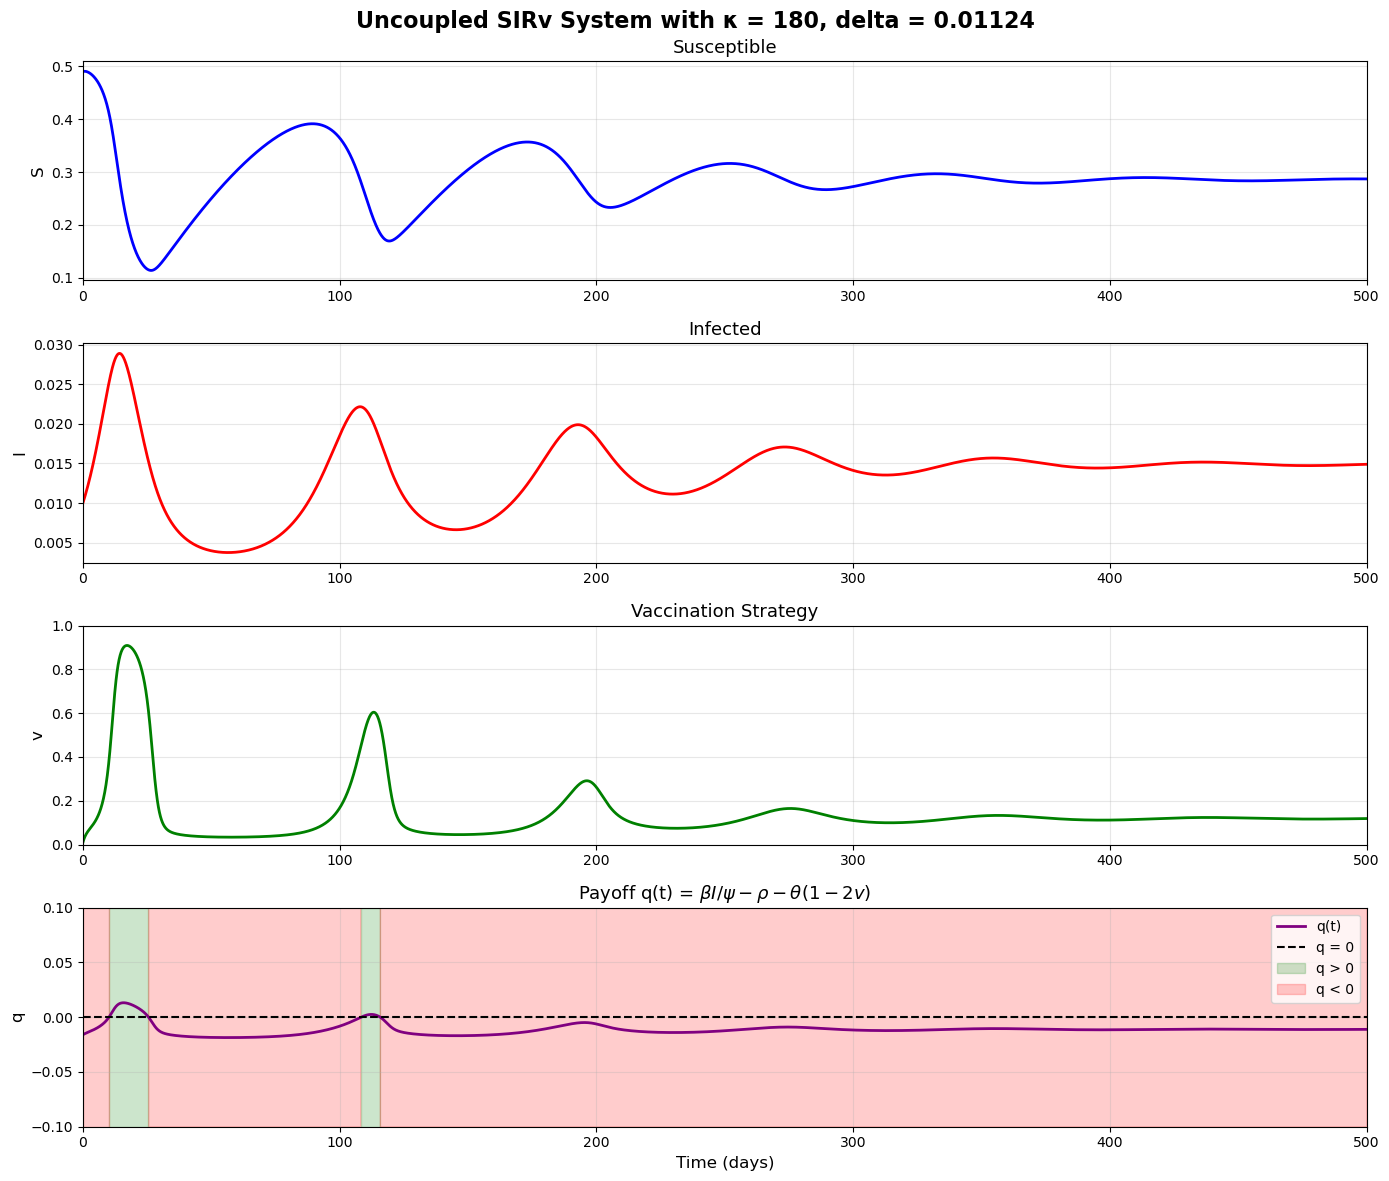

SIMULATION RESULTS (κ = 180)

Final values at t = 500.0 days:
S = 0.287015
I = 0.014899
v = 0.118925
q = -0.01111721

PAYOFF q STATISTICS
Mean q: -0.01124281
Min q: -0.01860570
Max q: 0.01318806
Std q: 0.00509171
Fraction of time q > 0: 0.0458
Fraction of time q < 0: 0.9542


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01124,
    'kappa': 180,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 1
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 180, delta = 0.01124', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

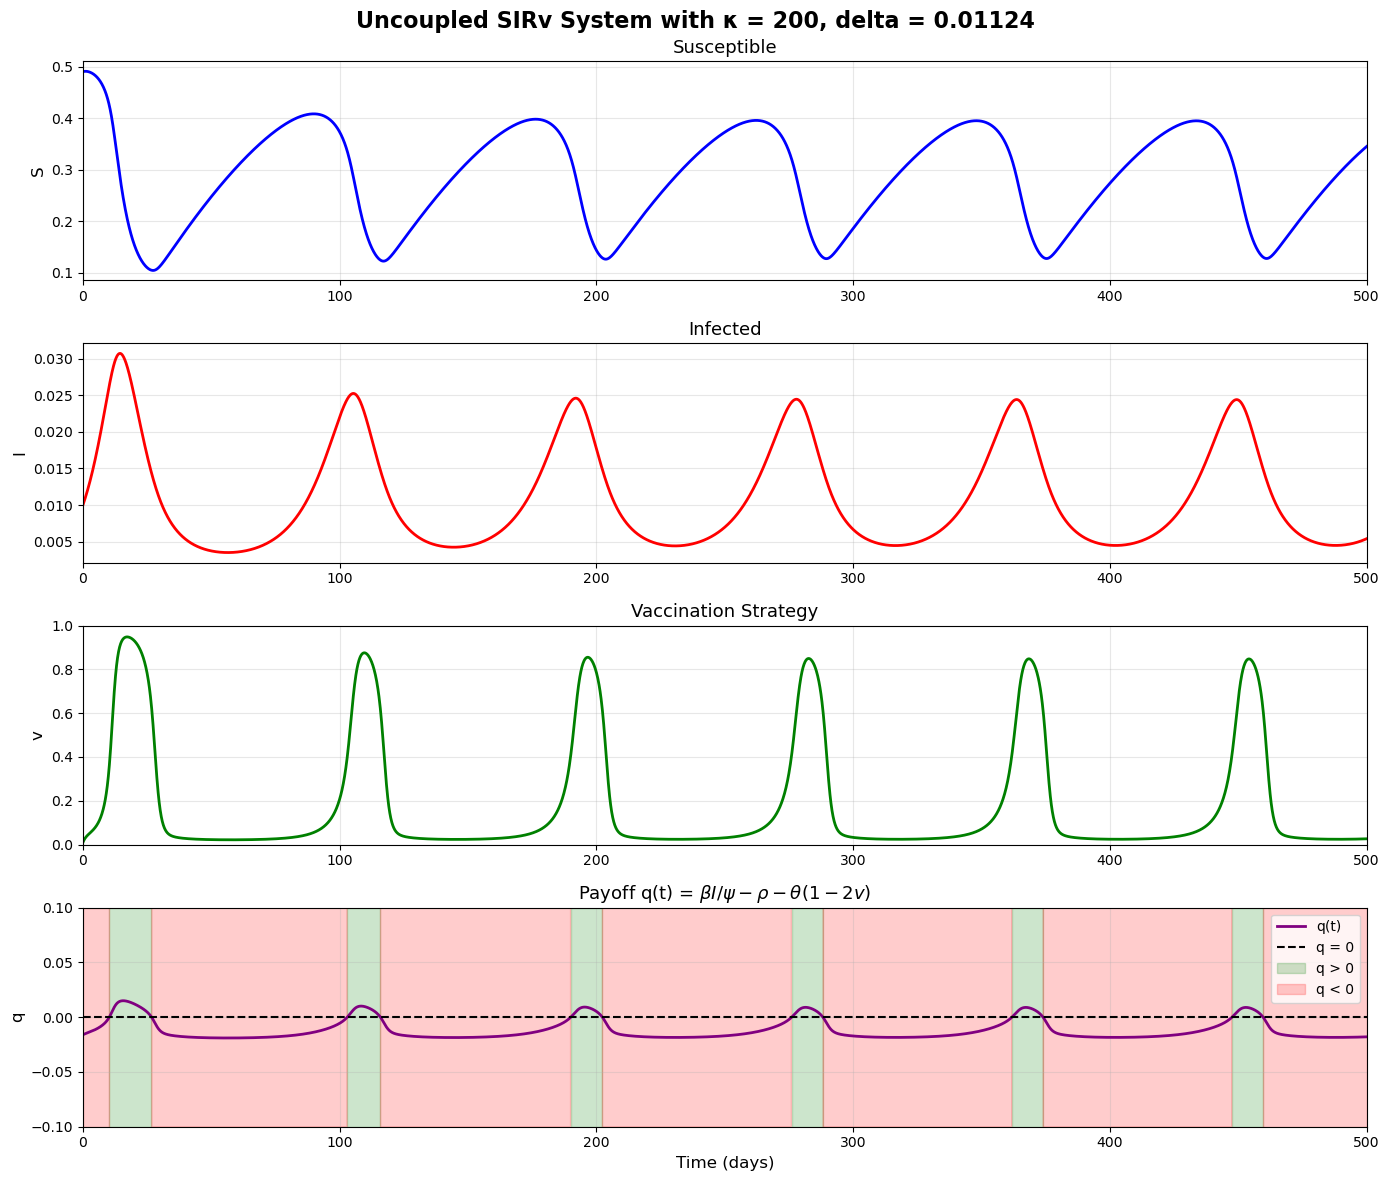

SIMULATION RESULTS (κ = 200)

Final values at t = 500.0 days:
S = 0.344934
I = 0.005422
v = 0.026529
q = -0.01793278

PAYOFF q STATISTICS
Mean q: -0.01171310
Min q: -0.01898140
Max q: 0.01503217
Std q: 0.00911198
Fraction of time q > 0: 0.1562
Fraction of time q < 0: 0.8438


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01124,
    'kappa': 200,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 1
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 200, delta = 0.01124', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")